
# Laboratorio 6 - Incisos 3 y 4 (Versión Corregida FINAL)

Correcciones aplicadas:
- Eliminación de multicolinealidad fuerte
- Simplificación de variables categóricas
- Variables numéricas mantenidas correctamente
- Modelo estable y convergente


In [10]:

import pandas as pd
import numpy as np
import pyreadr
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')


## Cargar datos

In [11]:

result = pyreadr.read_r("data/listings.RData")
df = list(result.values())[0]


## Limpieza de precio

In [12]:

df['price_clean'] = (
    df['price']
    .astype(str)
    .replace('[\$,]', '', regex=True)
    .replace('', np.nan)
)

df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')
df = df.dropna(subset=['price_clean'])


## Crear variable objetivo

In [13]:

q1 = df['price_clean'].quantile(0.33)
q2 = df['price_clean'].quantile(0.66)

def categorize_price(x):
    if x <= q1:
        return 'barato'
    elif x <= q2:
        return 'medio'
    else:
        return 'caro'

df['price_category'] = df['price_clean'].apply(categorize_price)
df['is_caro'] = (df['price_category'] == 'caro').astype(int)


## Selección de variables (corregida)

In [14]:

columns_numeric = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights',
    'availability_30',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'latitude', 'longitude'
]

columns_categorical = ['room_type']

df_model = df[columns_numeric + columns_categorical + ['is_caro']].copy()
df_model = df_model.dropna()


## Preparación de datos

In [15]:

X = df_model.drop(columns=['is_caro'])
y = df_model['is_caro']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Inciso 3: Modelo de Regresión Logística

In [16]:

model = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print("CV Accuracy:", cv_scores.mean())

model.fit(X_train_scaled, y_train)


CV Accuracy: 0.8167974755288918


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Inciso 4: Análisis del modelo (estable)

In [17]:
# Convertir a DataFrame
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)

# Alinear índices
X_train_df.index = y_train.index

# 1. Eliminar columnas con muy poca variabilidad
X_train_df = X_train_df.loc[:, X_train_df.std() > 0.01]

# 2. Eliminar columnas con valores extremos o infinitos
X_train_df = X_train_df.replace([np.inf, -np.inf], np.nan)
X_train_df = X_train_df.dropna(axis=1)

# 🔥 3. (Extra clave) eliminar correlación alta otra vez
corr_matrix = X_train_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X_train_df = X_train_df.drop(columns=to_drop)

print("Columnas eliminadas:", to_drop)

# 🔥 4. Modelo con método más estable
X_train_sm = sm.add_constant(X_train_df)

logit_model = sm.Logit(y_train, X_train_sm).fit(method='lbfgs', maxiter=200)

print(logit_model.summary())

Columnas eliminadas: ['longitude']
                           Logit Regression Results                           
Dep. Variable:                is_caro   No. Observations:                50174
Model:                          Logit   Df Residuals:                    50111
Method:                           MLE   Df Model:                           62
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.3089
Time:                        17:58:56   Log-Likelihood:                -21430.
converged:                       True   LL-Null:                       -31011.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.1551      1.159     -0.997      0.319      -3.426       1.116
accommodates                  0.5063      0.031    

## Matriz de correlación

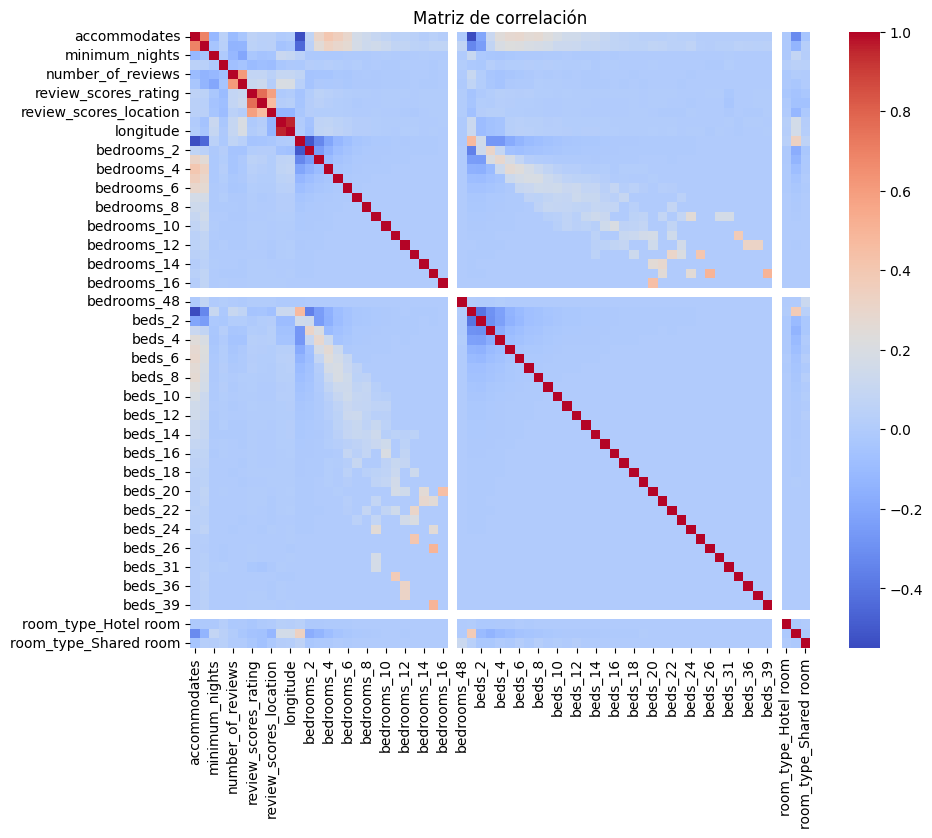

In [18]:

corr = pd.DataFrame(X_train_scaled, columns=X.columns).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()
